# Part E: Regularization (Ridge and Lasso Regression)

In this notebook, we implement **Ridge (L2)** and **Lasso (L1)** regression from scratch using NumPy. We will apply them to our cars dataset, compare their coefficients, and discuss how Lasso performs feature selection compared to Ridge regression.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Load and preprocess dataset (matching Part C exactly)
df = pd.read_csv('dataset/cars.csv')

# Drop rows with missing values in target variable
df = df.dropna(subset=['price_usd'])

# Separate features and target
y = df['price_usd']

# Select numeric features
numeric_features = ['manufacture_year', 'engine_cc', 'horsepower', 'mileage_km_per_l']

# Select categorical features
categorical_features = ['brand', 'body_type', 'fuel_type', 'transmission', 'manufacturing_country']

# One-hot encode categorical features
df_encoded = pd.get_dummies(df[categorical_features], drop_first=True, dtype=float)

# Combine numeric and encoded categorical features
X = pd.concat([df[numeric_features], df_encoded], axis=1)

# Remove rows with any missing values
complete_mask = ~(X.isna().any(axis=1))
X = X[complete_mask]
y = y[complete_mask]

print(f"Dataset size: {len(y)} samples")
print(f"Total features: {len(X.columns)}")

Dataset size: 300 samples
Total features: 26


In [3]:
# Feature scaling
X_original = X.copy()
X_max = X.max()
y_max = y.max()

X = X / X_max
X = X.values

y = y / y_max
y = y.values.reshape(-1, 1)

In [4]:
# Train-Test Split (80-20 split, seed 42)
np.random.seed(42)
n_samples = len(y)
indices = np.arange(n_samples)
np.random.shuffle(indices)

train_size = int(0.8 * n_samples)
train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X[train_indices]
X_test = X[test_indices]
y_train = y[train_indices]
y_test = y[test_indices]

# Prepend column of ones for intercept
X_train = np.c_[np.ones(len(X_train)), X_train]
X_test = np.c_[np.ones(len(X_test)), X_test]

## 1. Ridge Regression (L2 Regularization) from Scratch

The cost function for Ridge regression is:
$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2 + \frac{\lambda}{2m} \sum_{j=1}^{n} \theta_j^2$$

Note that we do not regularize the intercept term ($\theta_0$).

The gradient for $\theta_j$ is:
$$\frac{\partial J}{\partial \theta_0} = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})$$
$$\frac{\partial J}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) \cdot x_j^{(i)} + \frac{\lambda}{m} \theta_j \quad (\text{for } j \ge 1)$$

In [5]:
def fit_ridge(X, y, lmbda, lr=0.01, epochs=10000):
    m, n = X.shape
    theta = np.zeros((n, 1))
    costs = []
    
    for epoch in range(epochs):
        h = X @ theta
        error = h - y
        
        # L2 penalty excludes intercept (first parameter)
        reg_term = (lmbda / (2 * m)) * np.sum(np.square(theta[1:]))
        cost = (1 / (2 * m)) * np.sum(np.square(error)) + reg_term
        costs.append(cost)
        
        # Gradient computation
        grad_reg = (lmbda / m) * theta.copy()
        grad_reg[0] = 0 # Do not regularize intercept
        gradient = (1 / m) * (X.T @ error) + grad_reg
        
        theta = theta - lr * gradient
        
    return theta, costs

## 2. Lasso Regression (L1 Regularization) from Scratch

The cost function for Lasso regression is:
$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2 + \frac{\lambda}{m} \sum_{j=1}^{n} |\theta_j|$$

Again, we do not regularize the intercept term ($\theta_0$).

Since the absolute value function $|\theta_j|$ is not differentiable at $\theta_j = 0$, we use subgradient descent. The subgradient of $|\theta_j|$ is:
$$\text{sign}(\theta_j) = \begin{cases} 1 & \text{if } \theta_j > 0 \\ -1 & \text{if } \theta_j < 0 \\ 0 & \text{if } \theta_j = 0 \end{cases}$$

The gradient for $\theta_j$ is:
$$\frac{\partial J}{\partial \theta_0} = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})$$
$$\frac{\partial J}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) \cdot x_j^{(i)} + \frac{\lambda}{m} \text{sign}(\theta_j) \quad (\text{for } j \ge 1)$$

In [6]:
def fit_lasso(X, y, lmbda, lr=0.01, epochs=10000):
    m, n = X.shape
    theta = np.zeros((n, 1))
    costs = []
    
    for epoch in range(epochs):
        h = X @ theta
        error = h - y
        
        # L1 penalty excludes intercept
        reg_term = (lmbda / m) * np.sum(np.abs(theta[1:]))
        cost = (1 / (2 * m)) * np.sum(np.square(error)) + reg_term
        costs.append(cost)
        
        # Subgradient computation
        grad_reg = (lmbda / m) * np.sign(theta.copy())
        grad_reg[0] = 0 # Do not regularize intercept
        gradient = (1 / m) * (X.T @ error) + grad_reg
        
        theta = theta - lr * gradient
        
    return theta, costs

## 3. Training and Evaluation

Let's write a function to evaluate our models and compare Ridge and Lasso for different values of $\lambda$ (regularization strength).

In [7]:
def evaluate_model(theta, X, y, y_max):
    y_pred = (X @ theta) * y_max
    y_actual = y * y_max
    
    mse = (1 / len(y)) * np.sum(np.square(y_actual - y_pred))
    rmse = np.sqrt(mse)
    
    y_mean = np.mean(y_actual)
    ss_res = np.sum(np.square(y_actual - y_pred))
    ss_tot = np.sum(np.square(y_actual - y_mean))
    r2 = 1 - (ss_res / ss_tot)
    
    return mse, rmse, r2

In [8]:
# Train models with different values of lambda
lambdas = [0.0, 0.01, 0.1, 1.0, 5.0]
results = []
ridge_thetas = {}
lasso_thetas = {}

print("Training Ridge and Lasso Models...")
for l in lambdas:
    # Ridge
    t_ridge, c_ridge = fit_ridge(X_train, y_train, l, lr=0.01, epochs=10000)
    ridge_thetas[l] = t_ridge
    mse_tr_r, rmse_tr_r, r2_tr_r = evaluate_model(t_ridge, X_train, y_train, y_max)
    mse_te_r, rmse_te_r, r2_te_r = evaluate_model(t_ridge, X_test, y_test, y_max)
    
    # Lasso
    t_lasso, c_lasso = fit_lasso(X_train, y_train, l, lr=0.01, epochs=10000)
    lasso_thetas[l] = t_lasso
    mse_tr_l, rmse_tr_l, r2_tr_l = evaluate_model(t_lasso, X_train, y_train, y_max)
    mse_te_l, rmse_te_l, r2_te_l = evaluate_model(t_lasso, X_test, y_test, y_max)
    
    results.append({
        'lambda': l,
        'ridge_train_r2': r2_tr_r, 'ridge_test_r2': r2_te_r,
        'ridge_train_rmse': rmse_tr_r, 'ridge_test_rmse': rmse_te_r,
        'lasso_train_r2': r2_tr_l, 'lasso_test_r2': r2_te_l,
        'lasso_train_rmse': rmse_tr_l, 'lasso_test_rmse': rmse_te_l
    })

df_results = pd.DataFrame(results)
print("Training completed.")

Training Ridge and Lasso Models...


Training completed.


In [9]:
# Display results table
pd.set_option('display.float_format', lambda x: '%.4f' % x)
print(df_results.to_string(index=False))

 lambda  ridge_train_r2  ridge_test_r2  ridge_train_rmse  ridge_test_rmse  lasso_train_r2  lasso_test_r2  lasso_train_rmse  lasso_test_rmse
 0.0000          0.0953        -0.2405        32434.9398       38892.4643          0.0953        -0.2405        32434.9398       38892.4643
 0.0100          0.0953        -0.2404        32434.9920       38889.7002          0.0953        -0.2368        32435.8217       38833.6924
 0.1000          0.0953        -0.2388        32435.4917       38865.0504          0.0943        -0.2039        32454.0468       38313.8897
 1.0000          0.0949        -0.2244        32442.9998       38639.0775          0.0678        -0.0797        32924.6952       36283.1859
 5.0000          0.0915        -0.1805        32503.6322       37940.4859          0.0002        -0.0430        34097.4126       35661.3282


## 4. Comparing Coefficients and Feature Selection

A key difference between Ridge (L2) and Lasso (L1) regularization is feature selection:
- **Lasso (L1)** regularizes by penalizing the absolute magnitude of coefficients. This forces less important feature coefficients to be **exactly zero**, effectively performing feature selection.
- **Ridge (L2)** penalizes the squared magnitude of coefficients. This shrinks coefficients **close to zero** but never exactly zero, keeping all features in the model.

In [10]:
# Get feature names (excluding intercept)
feature_names = list(X_original.columns)

# Create coefficients comparison table for lambda = 1.0
l_val = 1.0
coef_comparison = pd.DataFrame({
    'Feature': feature_names,
    'MLR (No Reg)': ridge_thetas[0.0][1:].flatten() * y_max,
    'Ridge (Lambda=1.0)': ridge_thetas[l_val][1:].flatten() * y_max,
    'Lasso (Lambda=1.0)': lasso_thetas[l_val][1:].flatten() * y_max
})

print(coef_comparison.to_string(index=False))

                          Feature  MLR (No Reg)  Ridge (Lambda=1.0)  Lasso (Lambda=1.0)
                 manufacture_year    25003.1666          20697.3042             -2.1462
                        engine_cc    -7409.2434          -6323.6259             -2.0078
                       horsepower    20000.7426          19107.5043          15028.7007
                 mileage_km_per_l     2033.3734           2395.1467             -1.8140
                        brand_BMW    -1652.5214          -2164.1728            -15.0556
                       brand_Ford     6480.2095           5747.3889              2.2763
                      brand_Honda     -856.8846          -1385.7942              1.4943
                    brand_Hyundai     4136.7434           3365.8013              1.7945
                        brand_Kia     8948.9788           8128.2913            817.6913
                   brand_Mercedes    16078.1910          14834.7387           6988.5912
                     brand_Nissa

In [11]:
# Count non-zero coefficients
for l in lambdas:
    ridge_non_zero = np.sum(np.abs(ridge_thetas[l][1:]) > 1e-4)
    lasso_non_zero = np.sum(np.abs(lasso_thetas[l][1:]) > 1e-4)
    print(f"Lambda = {l}: Ridge non-zero coefficients = {ridge_non_zero}/{len(feature_names)}, Lasso non-zero coefficients = {lasso_non_zero}/{len(feature_names)}")

Lambda = 0.0: Ridge non-zero coefficients = 26/26, Lasso non-zero coefficients = 26/26
Lambda = 0.01: Ridge non-zero coefficients = 26/26, Lasso non-zero coefficients = 26/26
Lambda = 0.1: Ridge non-zero coefficients = 26/26, Lasso non-zero coefficients = 26/26
Lambda = 1.0: Ridge non-zero coefficients = 26/26, Lasso non-zero coefficients = 12/26
Lambda = 5.0: Ridge non-zero coefficients = 26/26, Lasso non-zero coefficients = 15/26


## 5. Visualizing Coefficient Shrinkage (Paths)

Let's plot how coefficient values change for each feature as we increase the regularization strength $\lambda$.

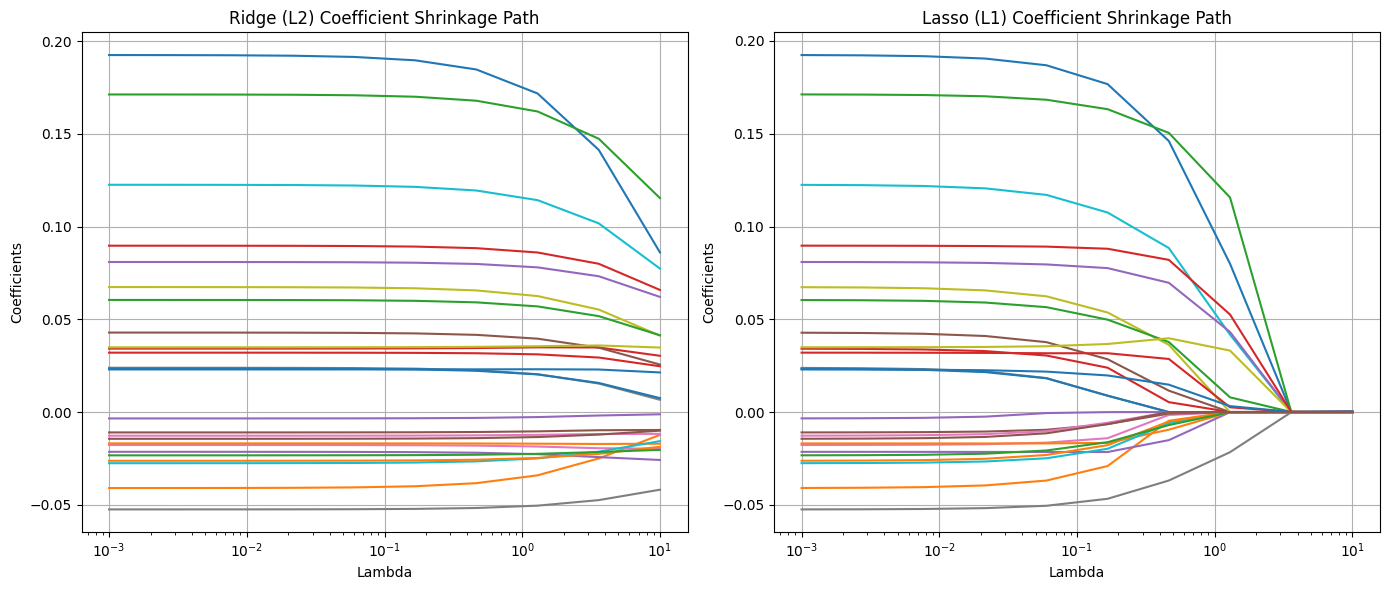

In [12]:
# Compute paths over a range of lambda values
path_lambdas = np.logspace(-3, 1, 10)
ridge_paths = []
lasso_paths = []

for l in path_lambdas:
    t_r, _ = fit_ridge(X_train, y_train, l, lr=0.01, epochs=5000)
    t_l, _ = fit_lasso(X_train, y_train, l, lr=0.01, epochs=5000)
    ridge_paths.append(t_r[1:].flatten())
    lasso_paths.append(t_l[1:].flatten())

ridge_paths = np.array(ridge_paths)
lasso_paths = np.array(lasso_paths)

plt.figure(figsize=(14, 6))

# Ridge Plot
plt.subplot(1, 2, 1)
for i in range(len(feature_names)):
    plt.plot(path_lambdas, ridge_paths[:, i], label=feature_names[i] if i < 5 else "")
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('Coefficients')
plt.title('Ridge (L2) Coefficient Shrinkage Path')
plt.grid(True)

# Lasso Plot
plt.subplot(1, 2, 2)
for i in range(len(feature_names)):
    plt.plot(path_lambdas, lasso_paths[:, i], label=feature_names[i] if i < 5 else "")
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('Coefficients')
plt.title('Lasso (L1) Coefficient Shrinkage Path')
plt.grid(True)

plt.tight_layout()
plt.show()

## 6. Key Observations & Conclusion

1. **Ridge Regression (L2)**: As $\lambda$ increases, the coefficients shrink towards zero but remain non-zero. It retains all features but reduces their magnitude, helping control multicollinearity and overfitting.
2. **Lasso Regression (L1)**: As $\lambda$ increases, many coefficients drop to **exactly 0**. In the coefficient path, we can clearly see lines hitting the 0 axis and staying there. This validates Lasso's role in **feature selection** and model simplification.
3. **Generalization**: Introducing a small amount of regularization helps reduce the generalization gap (difference between train and test performance) when dealing with complex, highly correlated datasets.